In [1]:
%pip install scikit-learn xgboost pyarrow pandas numpy matplotlib seaborn google-cloud-bigquery db_dtypes lightgbm catboost shap


Note: you may need to restart the kernel to use updated packages.


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
from google.cloud import bigquery
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, f1_score, accuracy_score
from xgboost import XGBClassifier
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.model_selection import cross_validate, StratifiedKFold
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import make_scorer, f1_score, roc_auc_score, precision_score, recall_score, classification_report, ConfusionMatrixDisplay, roc_curve, auc, RocCurveDisplay
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

client = bigquery.Client(project='project3grupo1')
print('Conexión OK')

Conexión OK


In [3]:
query = """
SELECT *
FROM `project3grupo1.dbt_transform.mart_occupancy_features`
WHERE date != '2026-05-15'
QUALIFY ROW_NUMBER() OVER (PARTITION BY listing_id, date ORDER BY listing_id) = 1
"""

df_raw = client.query(query).to_dataframe()
print(f'Shape: {df_raw.shape}')
print(df_raw.dtypes)

Shape: (3376585, 34)
is_occupied                    Int64
date                          dbdate
day_of_week                    Int64
month                          Int64
year                           Int64
is_weekend                     Int64
days_to_next_holiday           Int64
listing_id                     Int64
neighbourhood_cleansed        object
room_type                     object
accommodates                   Int64
bedrooms                     float64
beds                         float64
listing_price                float64
minimum_nights                 Int64
number_of_reviews              Int64
review_scores_rating         float64
review_scores_cleanliness    float64
review_scores_location       float64
review_scores_value          float64
instant_bookable             boolean
latitude                     float64
longitude                    float64
temp_max                     float64
temp_min                     float64
temp_mean                    float64
precipitation_mm 

In [4]:
TARGET = 'is_occupied'

FEATURES = [
    # Temporales
    'month', 'day_of_week', 'is_weekend', 'days_to_next_holiday', 'is_holiday',
    # Listing
    'neighbourhood_cleansed', 'room_type', 'accommodates', 'listing_price',
    'minimum_nights', 'number_of_reviews', 'review_scores_rating', 'instant_bookable',
    # Meteorología
    'temp_mean', 'precipitation_mm',
    # Eventos
    'num_sports', 'num_festivals', 'total_attendance',
]

df = df_raw[[TARGET] + FEATURES].copy()
print(f'Shape: {df.shape}')
print(f'Nulos:\n{df.isnull().sum()}')

Shape: (3376585, 19)
Nulos:
is_occupied                    0
month                          0
day_of_week                    0
is_weekend                     0
days_to_next_holiday           0
is_holiday                     0
neighbourhood_cleansed         0
room_type                      0
accommodates                   0
listing_price                  0
minimum_nights                 0
number_of_reviews              0
review_scores_rating      640547
instant_bookable               0
temp_mean                  12273
precipitation_mm           12273
num_sports                     0
num_festivals                  0
total_attendance               0
dtype: int64


In [5]:
df_raw[df_raw['temp_mean'].isnull()]['date'].value_counts()

date
2026-05-20    12273
Name: count, dtype: int64

In [6]:
df_raw = df_raw[df_raw['temp_mean'].notna()].copy()
print(f'Shape: {df_raw.shape}')

Shape: (3364312, 34)


In [7]:
df = df_raw[[TARGET] + FEATURES].copy()
print(f'Shape: {df.shape}')
print(f'Nulos:\n{df.isnull().sum()}')

Shape: (3364312, 19)
Nulos:
is_occupied                    0
month                          0
day_of_week                    0
is_weekend                     0
days_to_next_holiday           0
is_holiday                     0
neighbourhood_cleansed         0
room_type                      0
accommodates                   0
listing_price                  0
minimum_nights                 0
number_of_reviews              0
review_scores_rating      638215
instant_bookable               0
temp_mean                      0
precipitation_mm               0
num_sports                     0
num_festivals                  0
total_attendance               0
dtype: int64


In [8]:
X = df[FEATURES]
y = df[TARGET]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'Train: {X_train.shape}')
print(f'Test : {X_test.shape}')
print(f'Distribución train: {y_train.value_counts(normalize=True).round(3).to_dict()}')
print(f'Distribución test : {y_test.value_counts(normalize=True).round(3).to_dict()}')

Train: (2691449, 18)
Test : (672863, 18)
Distribución train: {np.int64(0): 0.627, np.int64(1): 0.373}
Distribución test : {np.int64(0): 0.627, np.int64(1): 0.373}


In [9]:
cap_cols = {
    'listing_price': X_train['listing_price'].quantile(0.99),
    'accommodates':  X_train['accommodates'].quantile(0.99),
}

X_train = X_train.copy()
X_test  = X_test.copy()

for col, upper in cap_cols.items():
    X_train[col] = X_train[col].clip(upper=upper)
    X_test[col]  = X_test[col].clip(upper=upper)

print('Caps aplicados:')
for col, upper in cap_cols.items():
    print(f'  {col}: upper={upper}')

Caps aplicados:
  listing_price: upper=1000.0
  accommodates: upper=12.0


In [10]:
num_cols = ['month', 'day_of_week', 'is_weekend', 'days_to_next_holiday', 'is_holiday',
            'accommodates', 'listing_price', 'minimum_nights', 'number_of_reviews',
            'review_scores_rating', 'instant_bookable', 'temp_mean', 'precipitation_mm',
            'num_sports', 'num_festivals', 'total_attendance']

cat_cols = ['neighbourhood_cleansed', 'room_type']

numeric_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler',  StandardScaler()),
])

categorical_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(drop='first', handle_unknown='ignore', sparse_output=False)),
])

preprocessor = ColumnTransformer([
    ('num', numeric_pipeline,         num_cols),
    ('cat', categorical_pipeline,     cat_cols),
])

X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed  = preprocessor.transform(X_test)

print(f'Shape train procesado: {X_train_processed.shape}')
print(f'Shape test procesado : {X_test_processed.shape}')

KeyboardInterrupt: 

In [ ]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

scorers = {
    'accuracy':  'accuracy',
    'f1':        make_scorer(f1_score, average='binary', zero_division=0),
    'precision': make_scorer(precision_score, average='binary', zero_division=0),
    'recall':    make_scorer(recall_score, average='binary', zero_division=0),
    'roc_auc':   'roc_auc',
}

#Averiaguamos en que proporcion aparece cada etiqueta de "y"
ratio = (y_train == 0).sum() / (y_train == 1).sum()

models = {
    #'XGBoost': XGBClassifier(n_estimators=300, max_depth=15, learning_rate=0.05, subsample=0.8, colsample_bytree=0.8, scale_pos_weight=ratio, eval_metric='logloss', random_state=42, n_jobs=-1),
    'LightGBM': LGBMClassifier(
    n_estimators=1000,          # Subimos el límite máximo de árboles...
    learning_rate=0.05,         # ...pero aprendemos más lento.
    num_leaves=63,              # Controlamos la complejidad por hojas (63 o 127 es ideal aquí)
    max_depth=-1,               # Dejamos que LightGBM optimice la profundidad naturalmente
    class_weight='balanced',    # ¡CRUCIAL! Penaliza más los errores en la clase 1 para subir el recall
    subsample=0.8,              # Usa el 80% de los datos por árbol (ahorra memoria/tiempo y evita overfitting)
    colsample_bytree=0.8,       # Usa el 80% de las features por árbol
    random_state=42,
    n_jobs=-1)
}

results = []
for name, model in models.items():
    print(f'Entrenando {name}...')
    cv_res = cross_validate(model, X_train_processed, y_train, cv=cv, scoring=scorers, return_train_score=True)
    results.append({
        'model':      name,
        'f1_test':    cv_res['test_f1'].mean(),
        'f1_train':   cv_res['train_f1'].mean(),
        'f1_std':     cv_res['test_f1'].std(),
        'auc':        cv_res['test_roc_auc'].mean(),
        'precision':  cv_res['test_precision'].mean(),
        'recall':     cv_res['test_recall'].mean(),
        'fit_time':   cv_res['fit_time'].mean(),
    })
    print(f'  F1={cv_res["test_f1"].mean():.4f}  AUC={cv_res["test_roc_auc"].mean():.4f}')

df_res = pd.DataFrame(results).sort_values('f1_test', ascending=False).reset_index(drop=True)
print(df_res.to_string(float_format='{:.4f}'.format))

Entrenando LightGBM...
[LightGBM] [Info] Number of positive: 797724, number of negative: 1339725
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.586520 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1215
[LightGBM] [Info] Number of data points in the train set: 2137449, number of used features: 87
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Start training from score 0.000000
[LightGBM] [Info] Number of positive: 797725, number of negative: 1339724
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.201241 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1213
[LightGBM] [Info] Number of data points in the train set: 2137449, number of used 

In [ ]:

lgbm_model.fit(X_train_processed, y_train)
y_proba = lgbm_model.predict_proba(X_test_processed)[:, 1]
umbral = 0.37
y_pred_opt = (y_proba >= umbral).astype(int)

print(f"\n--- Resultados con umbral ajustado ({umbral}) ---")
print(f"F1:        {f1_score(y_test, y_pred_opt):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_opt):.4f}")
print(f"Recall:    {recall_score(y_test, y_pred_opt):.4f}")
print(f"AUC:       {roc_auc_score(y_test, y_proba):.4f}")

[LightGBM] [Info] Number of positive: 997156, number of negative: 1674656
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.296849 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1214
[LightGBM] [Info] Number of data points in the train set: 2671812, number of used features: 87
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.373213 -> initscore=-0.518456
[LightGBM] [Info] Start training from score -0.518456

--- Resultados con umbral ajustado (0.37) ---
F1:        0.6184
Precision: 0.5837
Recall:    0.6574
AUC:       0.7549


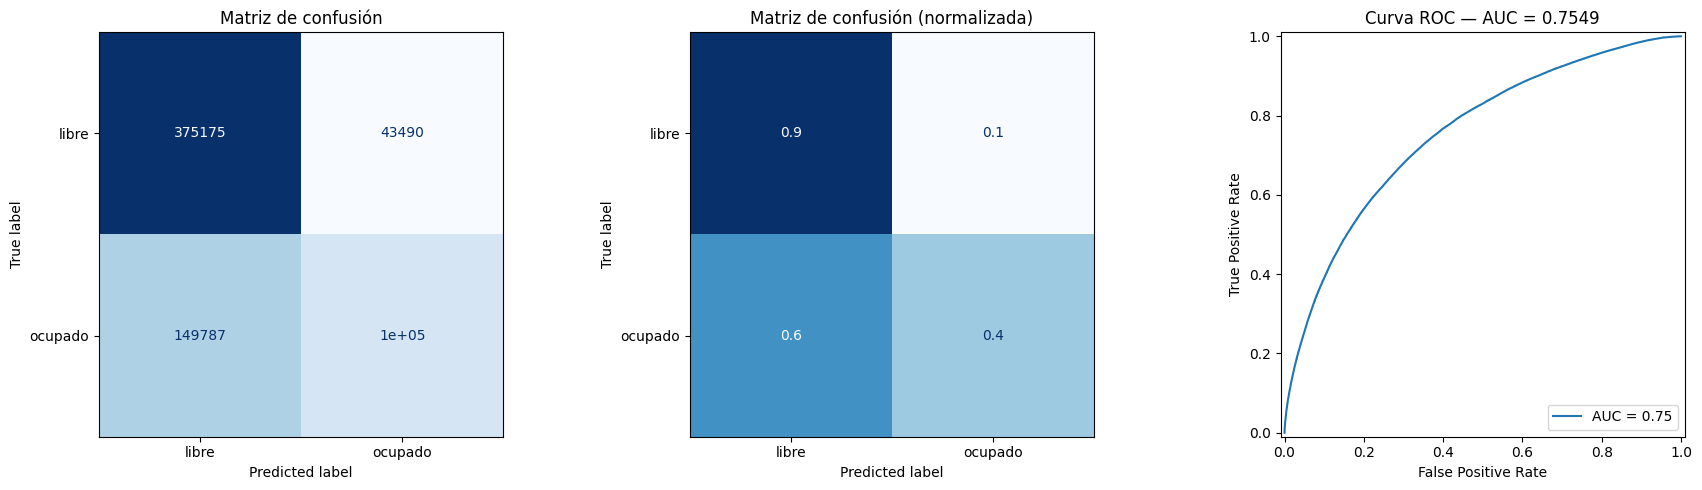

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Matriz de confusión
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred, ax=axes[0], cmap='Blues',
    colorbar=False, display_labels=['libre', 'ocupado']
)
axes[0].set_title('Matriz de confusión')

# Matriz normalizada
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred, ax=axes[1], cmap='Blues',
    colorbar=False, normalize='true', display_labels=['libre', 'ocupado']
)
axes[1].set_title('Matriz de confusión (normalizada)')

# Curva ROC
fpr, tpr, _ = roc_curve(y_test, y_proba)
roc_auc = auc(fpr, tpr)
RocCurveDisplay(fpr=fpr, tpr=tpr, roc_auc=roc_auc).plot(ax=axes[2])
axes[2].set_title(f'Curva ROC — AUC = {roc_auc:.4f}')

plt.tight_layout()
plt.show()

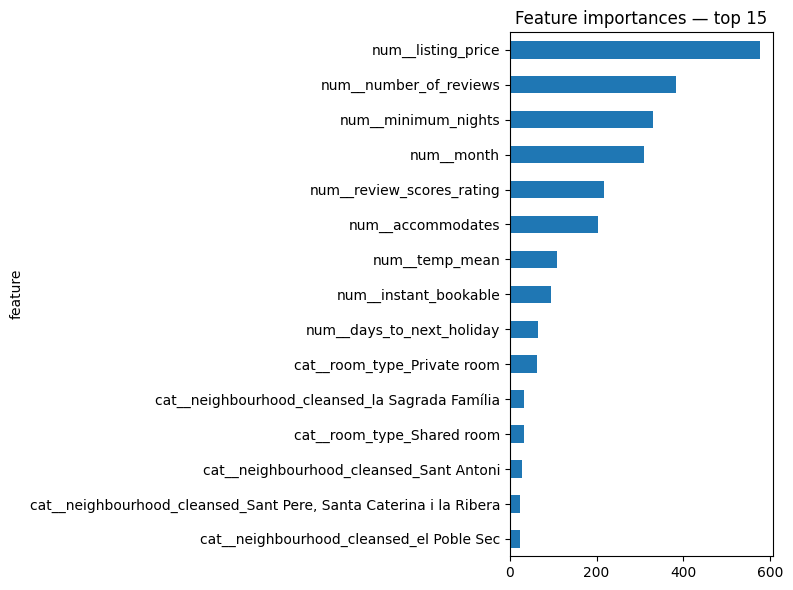

In [ ]:
feature_names = preprocessor.get_feature_names_out()

fi_df = pd.DataFrame({
    'feature':    feature_names,
    'importance': lgbm_model.feature_importances_,
}).sort_values('importance', ascending=False)

fi_df.head(15).plot(
    kind='barh', x='feature', y='importance',
    figsize=(8, 6), title='Feature importances — top 15', legend=False
)
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

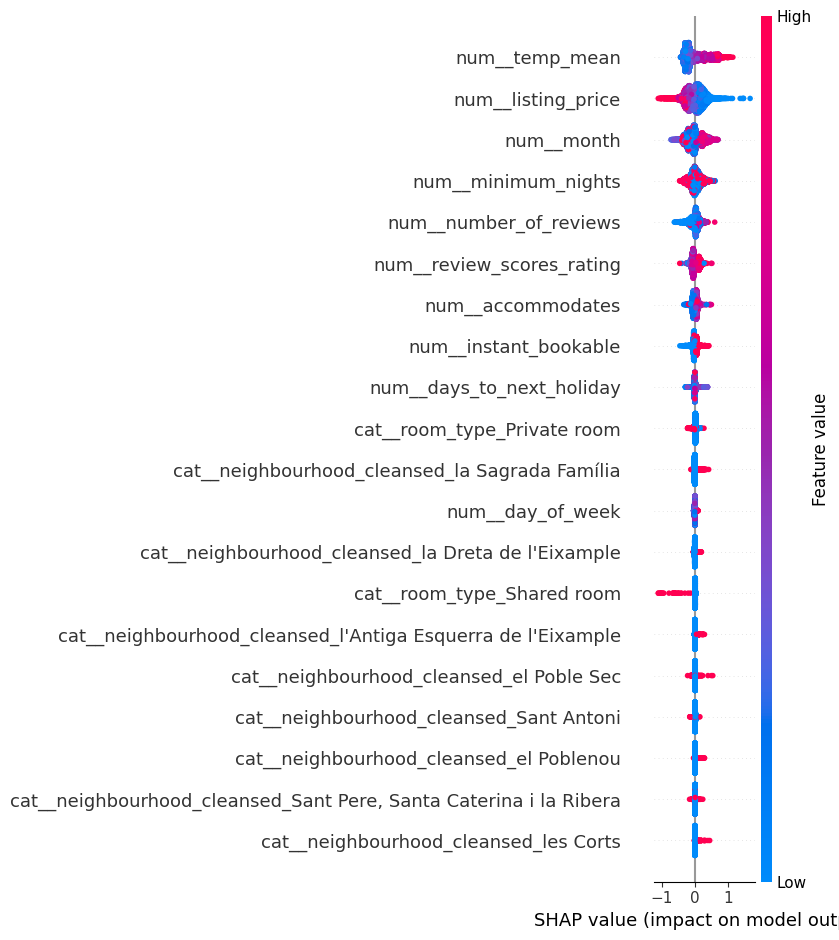

In [ ]:
import shap

explainer   = shap.TreeExplainer(lgbm_model)
shap_values = explainer.shap_values(X_test_processed[:5000])

shap.summary_plot(shap_values, X_test_processed[:5000], feature_names=feature_names)

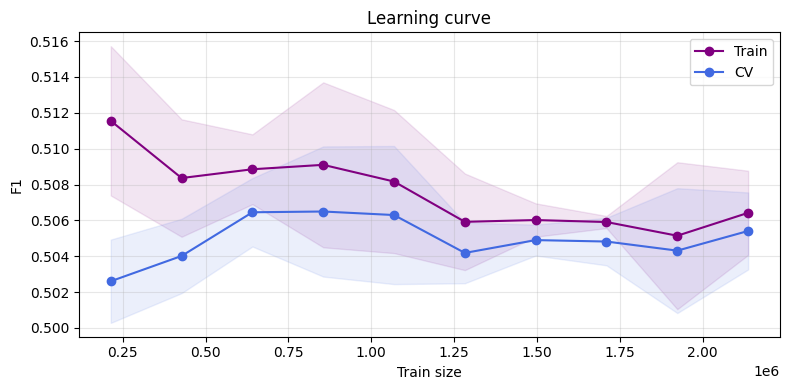

Gap final (F1): 0.0010


In [ ]:
from sklearn.model_selection import learning_curve

train_sizes, train_scores, val_scores = learning_curve(
    lgbm_model, X_train_processed, y_train,
    cv=cv, scoring='f1',
    train_sizes=np.linspace(0.1, 1.0, 10),
    n_jobs=-1, shuffle=True, random_state=42
)

tm, ts = train_scores.mean(axis=1), train_scores.std(axis=1)
vm, vs = val_scores.mean(axis=1),   val_scores.std(axis=1)

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(train_sizes, tm, 'o-', color='purple',    label='Train')
ax.plot(train_sizes, vm, 'o-', color='royalblue', label='CV')
ax.fill_between(train_sizes, tm-ts, tm+ts, alpha=0.1, color='purple')
ax.fill_between(train_sizes, vm-vs, vm+vs, alpha=0.1, color='royalblue')
ax.set(xlabel='Train size', ylabel='F1', title='Learning curve')
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(f'Gap final (F1): {tm[-1] - vm[-1]:.4f}')

# Conclusiones — Experimento 03

### Resultados
 | Modelo | F1 test | AUC | F1 train | Gap |
 |---|---|---|---|---|
 | LightGBM | 0.6184 | 0.7549 | 0.6184 | 0.001 |
 | XGBoost (depth=15) | 0.8350 | 0.9439 | 0.8648 | 0.03 |
#
 XGBoost seleccionado como mejor modelo: mejor F1, mejor AUC y menor overfitting.
#
 ## Drivers principales (SHAP)
 1. month — la estacionalidad es el predictor más importante
 2. listing_price — precios altos reducen ocupación
 3. temp_mean — el clima influye, correlacionado con estacionalidad
 4. number_of_reviews y minimum_nights — características del listing
#
 ## Limitaciones
 - Split aleatorio: no valida comportamiento temporal real.
   En exp_04 se usará split por fecha (train hasta X, test posterior)
 - listing_price puede tener fuga de datos: el precio puede
   ajustarse según ocupación esperada. A revisar en exp_04
 - Sin feature engineering: la tasa histórica de ocupación
   por listing y por barrio+mes puede mejorar el modelo significativamente
#
 ## Próximo experimento
 - Split temporal en lugar de aleatorio
 - Feature engineering: tasa histórica de ocupación por listing,
   tasa por barrio+mes
 - Revisar listing_price como posible fuga